# Hidden Markov Models (HMM) for Time Series

## What is an HMM?

A **Hidden Markov Model** is a statistical model where:
- The system is assumed to be a **Markov process** with unobservable (hidden) states
- We only observe **emissions** that depend on the current hidden state

## The Model

For a 2-state model (e.g., Bull/Bear market):

**State Transition:**
$$P(q_t = j \mid q_{t-1} = i) = a_{ij}$$

**Emission (Observation):**
$$P(y_t \mid q_t = k) = \mathcal{N}(\mu_k, \sigma_k^2)$$

## Key Algorithms

| Algorithm | Purpose |
|-----------|---------|
| **Forward** | Compute $P(q_t \mid y_{1:t})$ — filtered probabilities |
| **Backward** | Compute $P(y_{t+1:T} \mid q_t)$ — future evidence |
| **Forward-Backward** | Compute $P(q_t \mid y_{1:T})$ — smoothed probabilities |
| **Viterbi** | Find the most likely state sequence |
| **Baum-Welch (EM)** | Estimate parameters via Maximum Likelihood |

## Assumptions

- States follow a first-order Markov chain
- Emissions depend only on the current state
- Parameters are time-homogeneous

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================
# Generate Synthetic HMM Data
# ============================================
# Two-state HMM: Bull (high mean, low vol) vs Bear (low mean, high vol)

n = 300
n_states = 2

# True parameters
transition_true = np.array([[0.95, 0.05],   # P(stay Bull, Bull->Bear)
                            [0.10, 0.90]])  # P(Bear->Bull, stay Bear)

means_true = np.array([0.0008, -0.0010])     # Daily returns: Bull vs Bear
stds_true = np.array([0.008, 0.020])         # Volatility: Bull vs Bear

# Generate state sequence
states_true = np.zeros(n, dtype=int)
states_true[0] = 0  # Start in Bull
for t in range(1, n):
    states_true[t] = np.random.choice(n_states, p=transition_true[states_true[t-1]])

# Generate observations
obs = np.zeros(n)
for t in range(n):
    obs[t] = np.random.normal(means_true[states_true[t]], stds_true[states_true[t]])

time = np.arange(n)

df = pd.DataFrame({
    'time': time,
    'obs': obs,
    'state_true': states_true
})

print("HMM Data Generated!")
print(f"Observations: {n}")
print(f"Bull periods: {(states_true == 0).sum()}")
print(f"Bear periods: {(states_true == 1).sum()}")
print(f"\nTrue Transition Matrix:\n{transition_true}")
print(f"\nTrue Means: {means_true}")
print(f"True Stds:  {stds_true}")


HMM Data Generated!
Observations: 300
Bull periods: 201
Bear periods: 99

True Transition Matrix:
[[0.95 0.05]
 [0.1  0.9 ]]

True Means: [ 0.0008 -0.001 ]
True Stds:  [0.008 0.02 ]


In [54]:
# ============================================
# HMM Algorithms from Scratch
# ============================================

class HMM:
    def __init__(self, n_states=2):
        self.n_states = n_states
        self.pi = None
        self.A = None
        self.means = None
        self.stds = None
        
    def _emission_prob(self, obs, means, stds):
        probs = np.zeros((len(obs), self.n_states))
        for k in range(self.n_states):
            probs[:, k] = stats.norm.pdf(obs, means[k], stds[k])
        return probs
    
    def forward(self, obs, pi, A, means, stds):
        T = len(obs)
        alpha = np.zeros((T, self.n_states))
        c = np.zeros(T)
        B = self._emission_prob(obs, means, stds)
        
        alpha[0] = pi * B[0]
        c[0] = alpha[0].sum()
        alpha[0] /= c[0]
        
        for t in range(1, T):
            for j in range(self.n_states):
                alpha[t, j] = B[t, j] * np.sum(alpha[t-1] * A[:, j])
            c[t] = alpha[t].sum()
            alpha[t] /= c[t]
        
        return alpha, c
    
    def backward(self, obs, A, means, stds, c):
        T = len(obs)
        beta = np.zeros((T, self.n_states))
        beta[-1] = 1.0 / c[-1]
        
        for t in range(T-2, -1, -1):
            B_next = self._emission_prob(obs[t+1:t+2], means, stds)[0]
            for i in range(self.n_states):
                beta[t, i] = np.sum(A[i, :] * B_next * beta[t+1]) / c[t]
        
        return beta
    
    def forward_backward(self, obs, pi, A, means, stds):
        alpha, c = self.forward(obs, pi, A, means, stds)
        beta = self.backward(obs, A, means, stds, c)
        
        T = len(obs)
        gamma = np.zeros((T, self.n_states))
        xi = np.zeros((T-1, self.n_states, self.n_states))
        
        for t in range(T):
            denom = np.sum(alpha[t] * beta[t])
            if denom == 0:
                denom = 1e-10
            gamma[t] = (alpha[t] * beta[t]) / denom
        
        B = self._emission_prob(obs, means, stds)
        for t in range(T-1):
            denom = np.sum(alpha[t][:, None] * A * B[t+1][None, :] * beta[t+1][None, :])
            if denom == 0:
                denom = 1e-10
            xi[t] = (alpha[t][:, None] * A * B[t+1][None, :] * beta[t+1][None, :]) / denom
        
        return gamma, xi, c
    
    def viterbi(self, obs, pi, A, means, stds):
        T = len(obs)
        B = self._emission_prob(obs, means, stds)
        
        delta = np.zeros((T, self.n_states))
        psi = np.zeros((T, self.n_states), dtype=int)
        
        delta[0] = np.log(pi + 1e-10) + np.log(B[0] + 1e-10)
        
        for t in range(1, T):
            for j in range(self.n_states):
                probs = delta[t-1] + np.log(A[:, j] + 1e-10)
                psi[t, j] = np.argmax(probs)
                delta[t, j] = probs[psi[t, j]] + np.log(B[t, j] + 1e-10)
        
        states = np.zeros(T, dtype=int)
        states[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]
        
        return states
    
    def baum_welch(self, obs, n_iter=100, tol=1e-6):
        T = len(obs)
        
        # Initialize using quantiles
        sorted_obs = np.sort(obs)
        q25 = sorted_obs[int(T * 0.25)]
        q75 = sorted_obs[int(T * 0.75)]
        
        self.pi = np.array([0.6, 0.4])
        self.A = np.array([[0.9, 0.1], [0.15, 0.85]])
        self.means = np.array([q75, q25])
        self.stds = np.array([
            np.std(obs[obs > np.median(obs)]),
            np.std(obs[obs <= np.median(obs)])
        ])
        self.stds = np.clip(self.stds, 1e-6, None)
        
        log_likes = []
        
        for it in range(n_iter):
            gamma, xi, c = self.forward_backward(obs, self.pi, self.A, self.means, self.stds)
            
            ll = np.sum(np.log(c + 1e-300))
            log_likes.append(ll)
            
            if it > 0 and abs(log_likes[-1] - log_likes[-2]) < tol:
                break
            
            # M-step
            self.pi = gamma[0]
            self.A = xi.sum(axis=0) / (gamma[:-1].sum(axis=0)[:, None] + 1e-10)
            self.A = np.clip(self.A, 0.01, 0.99)
            self.A /= self.A.sum(axis=1, keepdims=True)
            
            for k in range(self.n_states):
                denom = gamma[:, k].sum() + 1e-10
                self.means[k] = np.sum(gamma[:, k] * obs) / denom
                self.stds[k] = np.sqrt(np.sum(gamma[:, k] * (obs - self.means[k])**2) / denom)
                self.stds[k] = max(self.stds[k], 1e-6)
        
        return log_likes


# Run HMM
hmm = HMM(n_states=2)
log_likes = hmm.baum_welch(obs, n_iter=200)

# Get results
gamma, xi, c = hmm.forward_backward(obs, hmm.pi, hmm.A, hmm.means, hmm.stds)
states_viterbi = hmm.viterbi(obs, hmm.pi, hmm.A, hmm.means, hmm.stds)

# Align states (HMM labels are permutation-invariant)
acc_0 = np.mean(states_viterbi == states_true)
acc_1 = np.mean((1 - states_viterbi) == states_true)
if acc_1 > acc_0:
    states_viterbi = 1 - states_viterbi
    gamma = gamma[:, [1, 0]]
    hmm.means = hmm.means[[1, 0]]
    hmm.stds = hmm.stds[[1, 0]]
    hmm.A = hmm.A[[1, 0], :][:, [1, 0]]

print("HMM Training Complete!")
print(f"Iterations: {len(log_likes)}")
print(f"Final Log-Likelihood: {log_likes[-1]:.2f}")
print(f"\nEstimated Transition Matrix:\n{hmm.A.round(3)}")
print(f"\nEstimated Means: {hmm.means.round(6)}")
print(f"Estimated Stds:  {hmm.stds.round(6)}")
print(f"\nViterbi Accuracy: {np.mean(states_viterbi == states_true):.1%}")


HMM Training Complete!
Iterations: 90
Final Log-Likelihood: 898.74

Estimated Transition Matrix:
[[0.979 0.021]
 [0.051 0.949]]

Estimated Means: [ 0.001541 -0.000521]
Estimated Stds:  [0.00889  0.019141]

Viterbi Accuracy: 83.3%


## Time Series with True vs Estimated Regimes

This plot shows the observed time series with the background colored by the underlying regime. The top panel shows the **true** regimes (known only in simulation), while the bottom panel shows the **Viterbi-estimated** regimes.

**What to look for:**
- Do the estimated regimes align with visible volatility clusters?
- Are the regime switches at intuitive points in the data?

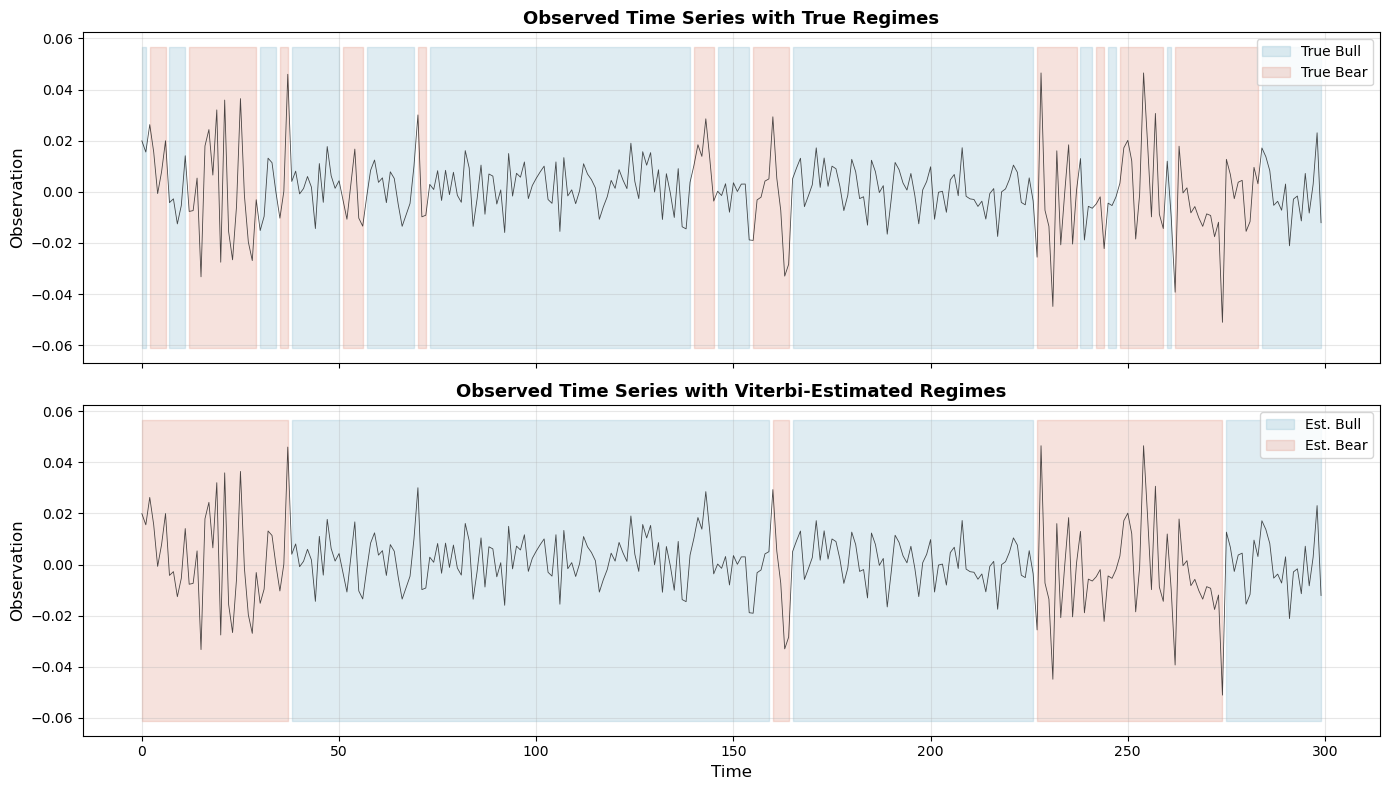

In [55]:
# ============================================
# Time Series with Regimes
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: True regimes
ax = axes[0]
bull_mask = states_true == 0
bear_mask = states_true == 1
ax.fill_between(time, obs.min() - 0.01, obs.max() + 0.01, 
                where=bull_mask, color='#2E86AB', alpha=0.15, label='True Bull')
ax.fill_between(time, obs.min() - 0.01, obs.max() + 0.01, 
                where=bear_mask, color='#C73E1D', alpha=0.15, label='True Bear')
ax.plot(time, obs, '-', color='black', linewidth=0.6, alpha=0.7)
ax.set_ylabel('Observation', fontsize=12)
ax.set_title('Observed Time Series with True Regimes', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Bottom: Estimated regimes
ax = axes[1]
viterbi_bull = states_viterbi == 0
viterbi_bear = states_viterbi == 1
ax.fill_between(time, obs.min() - 0.01, obs.max() + 0.01, 
                where=viterbi_bull, color='#2E86AB', alpha=0.15, label='Est. Bull')
ax.fill_between(time, obs.min() - 0.01, obs.max() + 0.01, 
                where=viterbi_bear, color='#C73E1D', alpha=0.15, label='Est. Bear')
ax.plot(time, obs, '-', color='black', linewidth=0.6, alpha=0.7)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Observation', fontsize=12)
ax.set_title('Observed Time Series with Viterbi-Estimated Regimes', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Smoothed State Probabilities

The **Forward-Backward algorithm** computes the probability of being in each state at each time point, using **all** observations (past and future).

**Filtered probabilities** use only data up to time $t$ (from the Forward pass).
**Smoothed probabilities** use the full sample (Forward-Backward).

Smoothed probabilities are generally more confident (closer to 0 or 1) because they use more information.


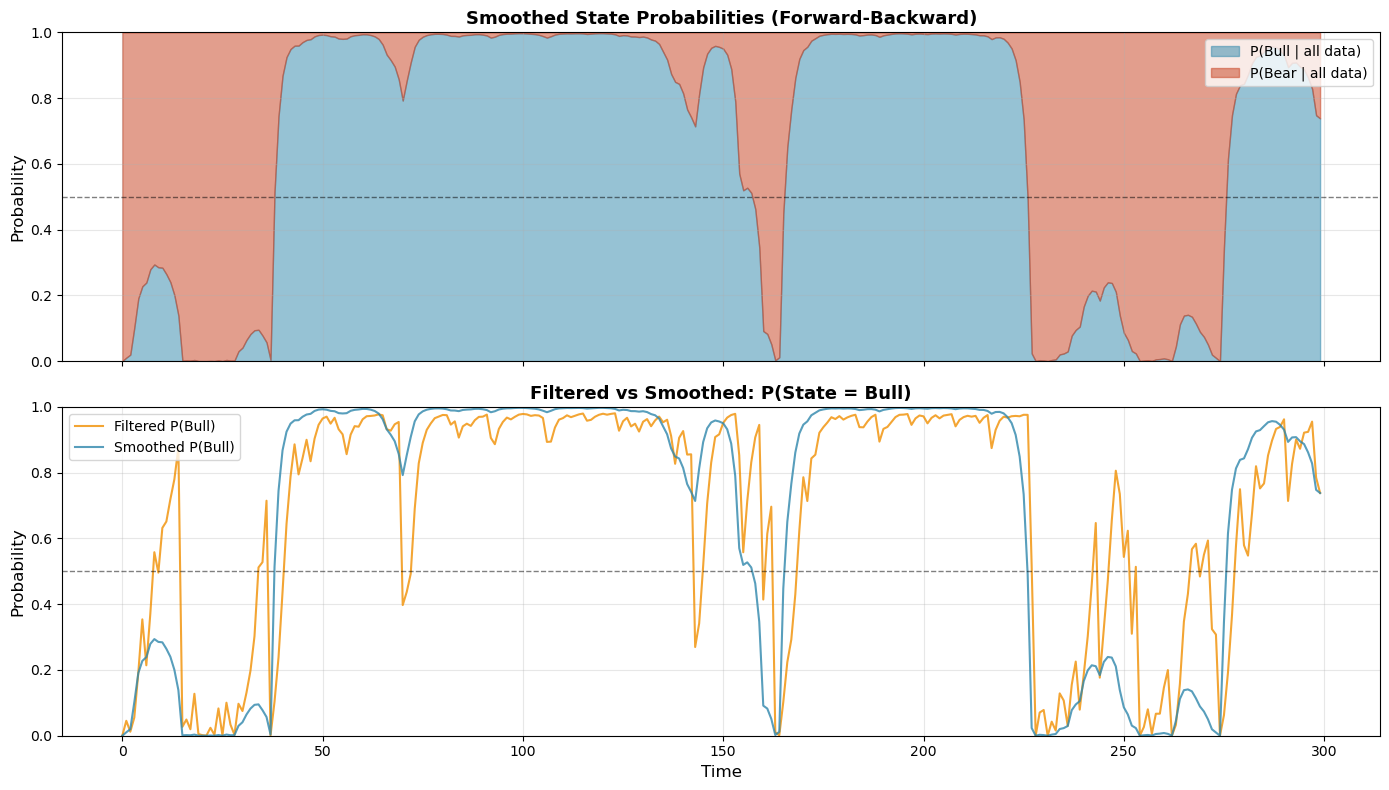

In [56]:
# ============================================
# Smoothed State Probabilities
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Stacked probability area
ax = axes[0]
ax.fill_between(time, 0, gamma[:, 0], color='#2E86AB', alpha=0.5, label='P(Bull | all data)')
ax.fill_between(time, gamma[:, 0], 1, color='#C73E1D', alpha=0.5, label='P(Bear | all data)')
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Smoothed State Probabilities (Forward-Backward)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Bottom: Filtered vs Smoothed for State 0
ax = axes[1]
alpha_scaled, _ = hmm.forward(obs, hmm.pi, hmm.A, hmm.means, hmm.stds)
ax.plot(time, alpha_scaled[:, 0], '-', color='#F18F01', linewidth=1.5, alpha=0.8, label='Filtered P(Bull)')
ax.plot(time, gamma[:, 0], '-', color='#2E86AB', linewidth=1.5, alpha=0.8, label='Smoothed P(Bull)')
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Filtered vs Smoothed: P(State = Bull)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Transition Matrix & Emission Distributions

**Left:** The true transition matrix vs. the EM-estimated matrix. High diagonal values indicate **persistent** regimes (rare switches).

**Right:** The estimated Gaussian emission distributions for each state. Well-separated distributions make state identification easy; overlapping distributions make it difficult.


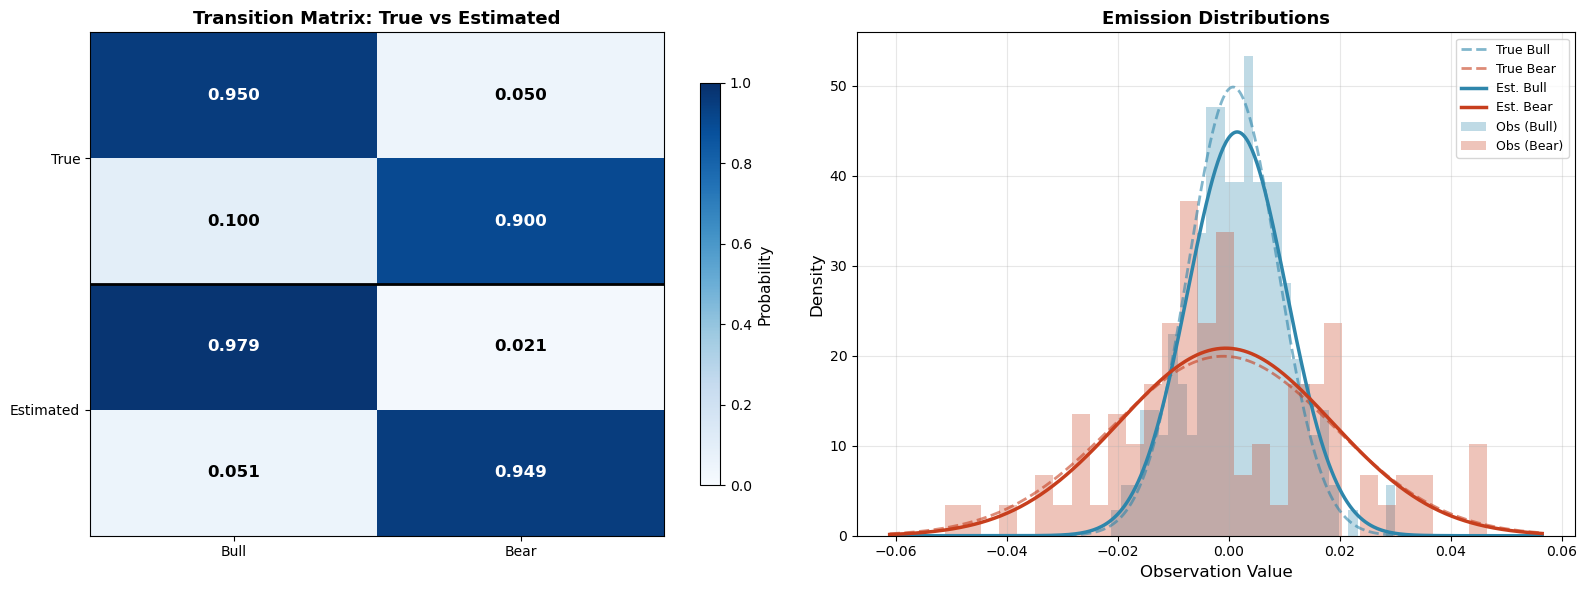

In [57]:
# ============================================
# Transition Matrix + Emission Distributions
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Transition matrices comparison
ax = axes[0]
n = hmm.n_states
combined = np.zeros((n * 2, n))
combined[:n, :] = transition_true
combined[n:, :] = hmm.A

im = ax.imshow(combined, cmap='Blues', vmin=0, vmax=1, aspect='auto')
for i in range(n * 2):
    for j in range(n):
        val = combined[i, j]
        text_color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                color=text_color, fontsize=12, fontweight='bold')

ax.set_xticks(range(n))
ax.set_xticklabels(['Bull', 'Bear'])
ax.set_yticks([0.5, 2.5])
ax.set_yticklabels(['True', 'Estimated'])
ax.set_title('Transition Matrix: True vs Estimated', fontsize=13, fontweight='bold')
ax.axhline(y=1.5, color='black', linewidth=2)
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Probability', fontsize=11)

# Right: Emission distributions
ax = axes[1]
x_range = np.linspace(obs.min() - 0.01, obs.max() + 0.01, 500)

# True distributions
for mean, std, color, label in zip(means_true, stds_true, 
                                    ['#2E86AB', '#C73E1D'],
                                    ['True Bull', 'True Bear']):
    ax.plot(x_range, stats.norm.pdf(x_range, mean, std), '--', 
            color=color, linewidth=2, alpha=0.6, label=label)

# Estimated distributions
for mean, std, color, label in zip(hmm.means, hmm.stds,
                                    ['#2E86AB', '#C73E1D'],
                                    ['Est. Bull', 'Est. Bear']):
    ax.plot(x_range, stats.norm.pdf(x_range, mean, std), '-',
            color=color, linewidth=2.5, label=label)

# Histograms
bull_obs = obs[states_viterbi == 0]
bear_obs = obs[states_viterbi == 1]
ax.hist(bull_obs, bins=30, color='#2E86AB', alpha=0.3, density=True, label='Obs (Bull)')
ax.hist(bear_obs, bins=30, color='#C73E1D', alpha=0.3, density=True, label='Obs (Bear)')

ax.set_xlabel('Observation Value', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Emission Distributions', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## EM Convergence & Regime Duration

**Left:** The Baum-Welch EM algorithm maximizes the log-likelihood iteratively. Convergence is typically fast for well-specified models.

**Right:** The distribution of how long the process stays in each regime. For a Markov chain, the expected duration in state $i$ is $1 / (1 - a_{ii})$.


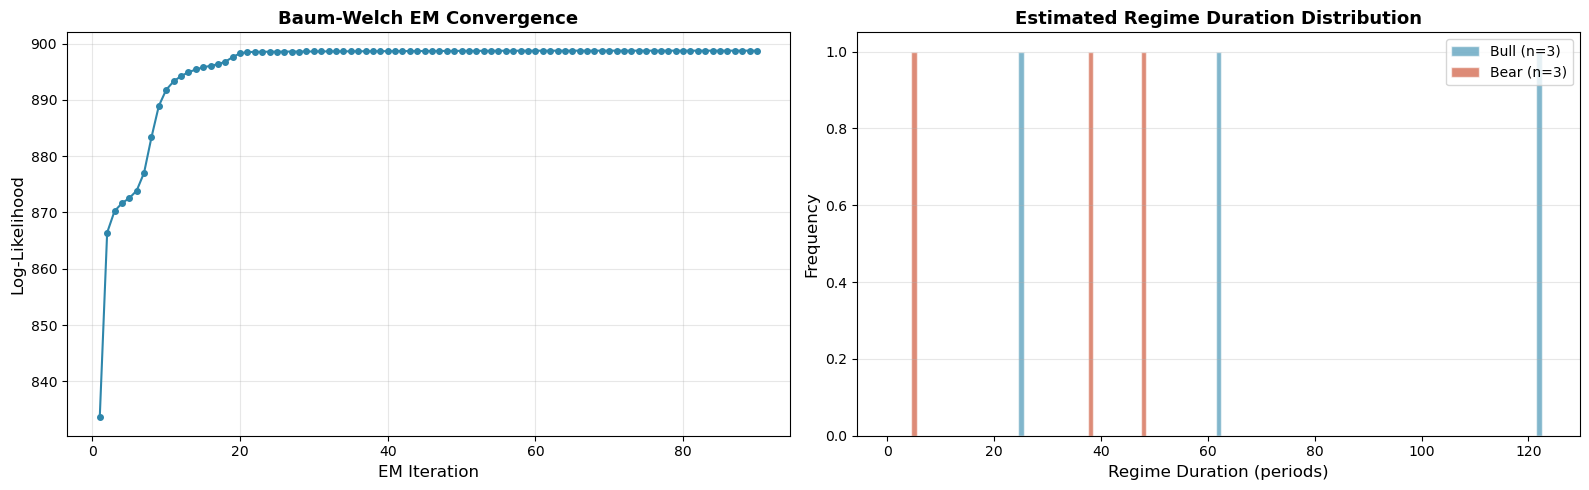

Avg Bull duration: 69.7
Avg Bear duration: 30.3
Expected Bull duration: 46.7
Expected Bear duration: 19.6


In [58]:
# ============================================
# Log-Likelihood Convergence + Regime Duration
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: EM convergence
ax = axes[0]
ax.plot(range(1, len(log_likes) + 1), log_likes, '-o', color='#2E86AB', 
        markersize=4, linewidth=1.5)
ax.set_xlabel('EM Iteration', fontsize=12)
ax.set_ylabel('Log-Likelihood', fontsize=12)
ax.set_title('Baum-Welch EM Convergence', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Right: Regime duration distribution
ax = axes[1]

def get_durations(states):
    durations = []
    current = states[0]
    count = 1
    for s in states[1:]:
        if s == current:
            count += 1
        else:
            durations.append((current, count))
            current = s
            count = 1
    durations.append((current, count))
    return durations

durations = get_durations(states_viterbi)
bull_durations = [d for s, d in durations if s == 0]
bear_durations = [d for s, d in durations if s == 1]

bins = np.arange(1, max(max(bull_durations, default=1), max(bear_durations, default=1)) + 3)
ax.hist(bull_durations, bins=bins, color='#2E86AB', alpha=0.6, edgecolor='white', 
        label=f'Bull (n={len(bull_durations)})', align='left')
ax.hist(bear_durations, bins=bins, color='#C73E1D', alpha=0.6, edgecolor='white',
        label=f'Bear (n={len(bear_durations)})', align='left')

ax.set_xlabel('Regime Duration (periods)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Estimated Regime Duration Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Avg Bull duration: {np.mean(bull_durations):.1f}")
print(f"Avg Bear duration: {np.mean(bear_durations):.1f}")
print(f"Expected Bull duration: {1/(1-hmm.A[0,0]):.1f}")
print(f"Expected Bear duration: {1/(1-hmm.A[1,1]):.1f}")


## Confusion Matrix & Residuals by Regime

**Left:** A confusion matrix comparing true states to Viterbi-decoded states. High diagonal values indicate accurate classification.

**Right:** Residuals (observation minus regime mean) should be approximately Gaussian within each regime if the model is well-specified.


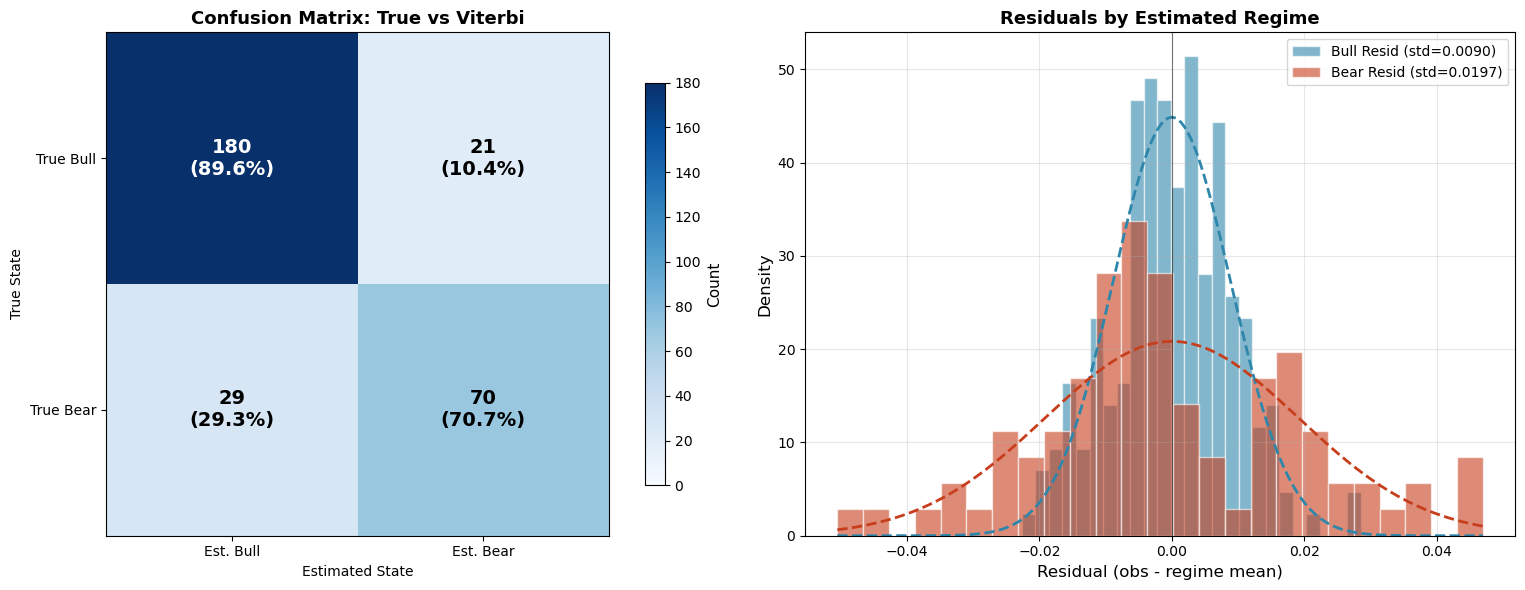

In [59]:
# ============================================
# Confusion Matrix + Residuals by Regime
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Confusion Matrix
ax = axes[0]
T = len(obs)
confusion = np.zeros((2, 2), dtype=int)
for t in range(T):
    confusion[states_true[t], states_viterbi[t]] += 1

im = ax.imshow(confusion, cmap='Blues', vmin=0)
for i in range(2):
    for j in range(2):
        val = confusion[i, j]
        row_sum = confusion[i, :].sum()
        pct = val / row_sum * 100 if row_sum > 0 else 0
        text_color = 'white' if val > confusion.max() * 0.5 else 'black'
        ax.text(j, i, f'{val}\n({pct:.1f}%)', ha='center', va='center',
                color=text_color, fontsize=14, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Est. Bull', 'Est. Bear'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['True Bull', 'True Bear'])
ax.set_title('Confusion Matrix: True vs Viterbi', fontsize=13, fontweight='bold')
ax.set_xlabel('Estimated State')
ax.set_ylabel('True State')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Count', fontsize=11)

# Right: Residuals by regime
ax = axes[1]
residuals = np.zeros(T)
for t in range(T):
    residuals[t] = obs[t] - hmm.means[states_viterbi[t]]

bull_resid = residuals[states_viterbi == 0]
bear_resid = residuals[states_viterbi == 1]

ax.hist(bull_resid, bins=25, color='#2E86AB', alpha=0.6, edgecolor='white',
        density=True, label=f'Bull Resid (std={np.std(bull_resid):.4f})')
ax.hist(bear_resid, bins=25, color='#C73E1D', alpha=0.6, edgecolor='white',
        density=True, label=f'Bear Resid (std={np.std(bear_resid):.4f})')

x_range = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(x_range, stats.norm.pdf(x_range, 0, hmm.stds[0]), '--', color='#2E86AB', linewidth=2)
ax.plot(x_range, stats.norm.pdf(x_range, 0, hmm.stds[1]), '--', color='#C73E1D', linewidth=2)

ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Residual (obs - regime mean)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Residuals by Estimated Regime', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## HMM Dashboard

A consolidated dashboard combining all key diagnostics into one figure.


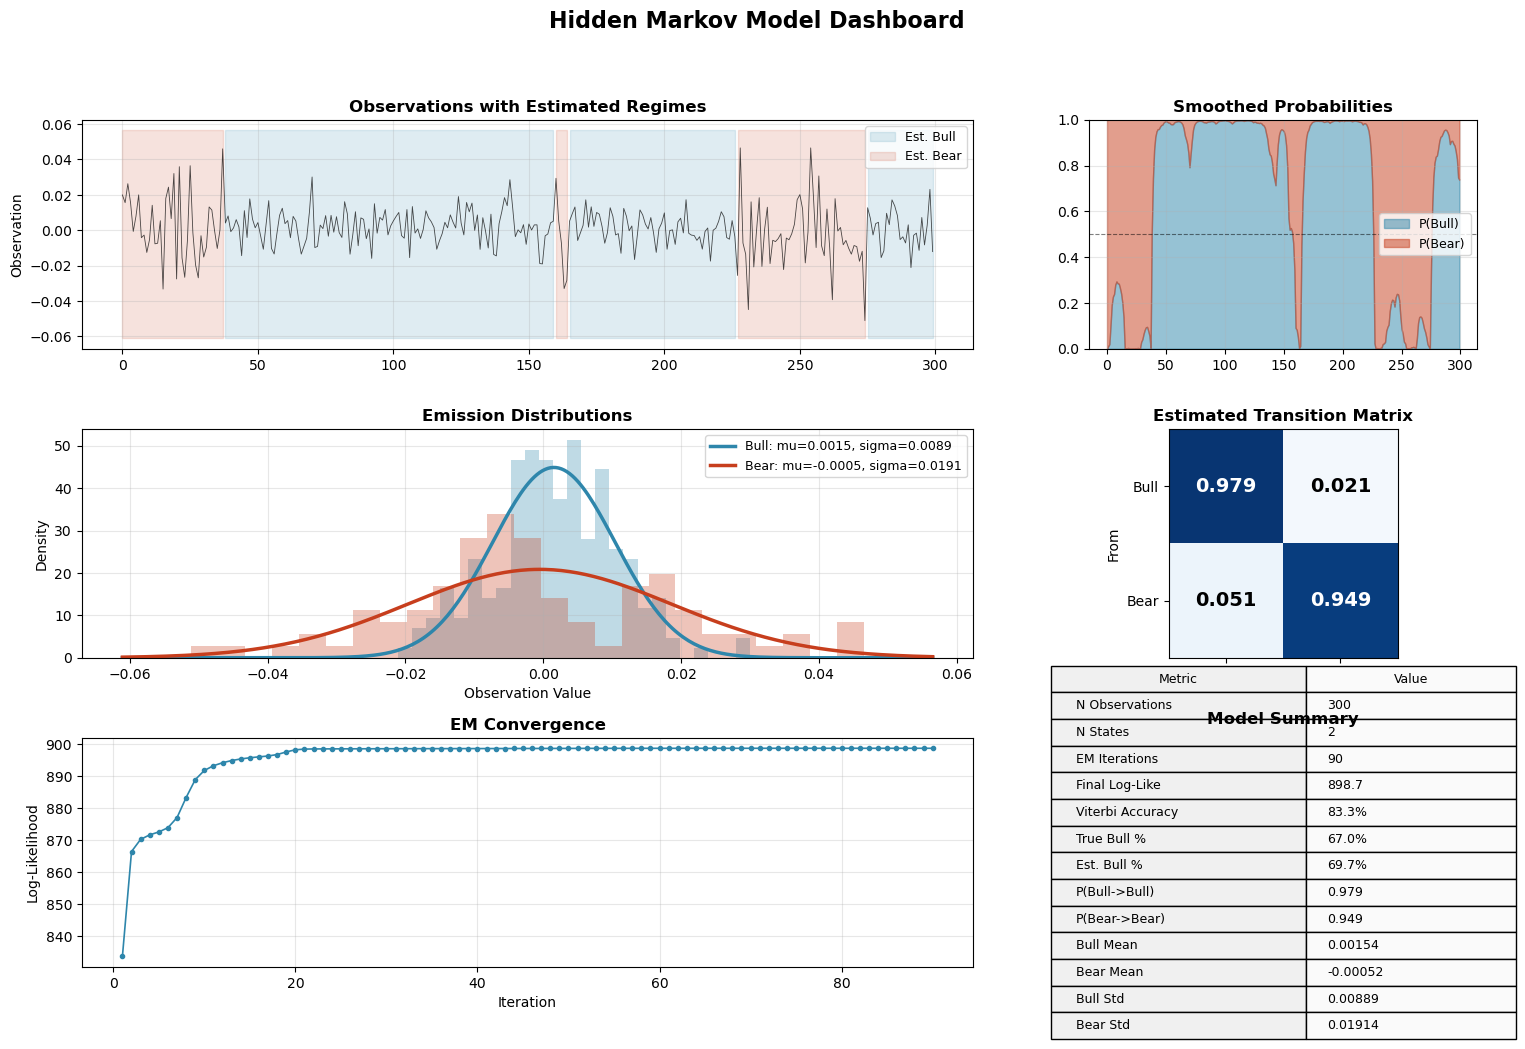

In [60]:
# ============================================
# HMM Dashboard
# ============================================

fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# --- Top Left: Time Series with Regimes ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.fill_between(time, obs.min() - 0.01, obs.max() + 0.01,
                 where=(states_viterbi == 0), color='#2E86AB', alpha=0.15, label='Est. Bull')
ax1.fill_between(time, obs.min() - 0.01, obs.max() + 0.01,
                 where=(states_viterbi == 1), color='#C73E1D', alpha=0.15, label='Est. Bear')
ax1.plot(time, obs, '-', color='black', linewidth=0.6, alpha=0.7)
ax1.set_title('Observations with Estimated Regimes', fontsize=12, fontweight='bold')
ax1.set_ylabel('Observation')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Top Right: Smoothed Probabilities ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.fill_between(time, 0, gamma[:, 0], color='#2E86AB', alpha=0.5, label='P(Bull)')
ax2.fill_between(time, gamma[:, 0], 1, color='#C73E1D', alpha=0.5, label='P(Bear)')
ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_title('Smoothed Probabilities', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Middle Left: Emission Distributions ---
ax3 = fig.add_subplot(gs[1, :2])
x_range = np.linspace(obs.min() - 0.01, obs.max() + 0.01, 300)
ax3.plot(x_range, stats.norm.pdf(x_range, hmm.means[0], hmm.stds[0]), '-',
         color='#2E86AB', linewidth=2.5, label=f'Bull: mu={hmm.means[0]:.4f}, sigma={hmm.stds[0]:.4f}')
ax3.plot(x_range, stats.norm.pdf(x_range, hmm.means[1], hmm.stds[1]), '-',
         color='#C73E1D', linewidth=2.5, label=f'Bear: mu={hmm.means[1]:.4f}, sigma={hmm.stds[1]:.4f}')
ax3.hist(obs[states_viterbi == 0], bins=25, color='#2E86AB', alpha=0.3, density=True)
ax3.hist(obs[states_viterbi == 1], bins=25, color='#C73E1D', alpha=0.3, density=True)
ax3.set_title('Emission Distributions', fontsize=12, fontweight='bold')
ax3.set_xlabel('Observation Value')
ax3.set_ylabel('Density')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# --- Middle Right: Transition Matrix ---
ax4 = fig.add_subplot(gs[1, 2])
im = ax4.imshow(hmm.A, cmap='Blues', vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax4.text(j, i, f'{hmm.A[i,j]:.3f}', ha='center', va='center',
                color='white' if hmm.A[i,j] > 0.5 else 'black', fontsize=14, fontweight='bold')
ax4.set_xticks([0, 1])
ax4.set_xticklabels(['Bull', 'Bear'])
ax4.set_yticks([0, 1])
ax4.set_yticklabels(['Bull', 'Bear'])
ax4.set_title('Estimated Transition Matrix', fontsize=12, fontweight='bold')
ax4.set_xlabel('To')
ax4.set_ylabel('From')

# --- Bottom Left: EM Convergence ---
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(range(1, len(log_likes) + 1), log_likes, '-o', color='#2E86AB',
         markersize=3, linewidth=1.2)
ax5.set_title('EM Convergence', fontsize=12, fontweight='bold')
ax5.set_xlabel('Iteration')
ax5.set_ylabel('Log-Likelihood')
ax5.grid(True, alpha=0.3)

# --- Bottom Right: Metrics Table ---
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')

T = len(obs)
accuracy = np.mean(states_viterbi == states_true)

metrics = [
    ['N Observations', f'{T}'],
    ['N States', f'{hmm.n_states}'],
    ['EM Iterations', f'{len(log_likes)}'],
    ['Final Log-Like', f'{log_likes[-1]:.1f}'],
    ['Viterbi Accuracy', f'{accuracy:.1%}'],
    ['True Bull %', f'{(states_true == 0).mean():.1%}'],
    ['Est. Bull %', f'{(states_viterbi == 0).mean():.1%}'],
    ['P(Bull->Bull)', f'{hmm.A[0,0]:.3f}'],
    ['P(Bear->Bear)', f'{hmm.A[1,1]:.3f}'],
    ['Bull Mean', f'{hmm.means[0]:.5f}'],
    ['Bear Mean', f'{hmm.means[1]:.5f}'],
    ['Bull Std', f'{hmm.stds[0]:.5f}'],
    ['Bear Std', f'{hmm.stds[1]:.5f}'],
]

table = ax6.table(cellText=metrics, colLabels=['Metric', 'Value'],
                  cellLoc='left', loc='center', colWidths=[0.55, 0.45])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.6)
for i in range(len(metrics) + 1):
    table[(i, 0)].set_facecolor('#f0f0f0')
    table[(i, 1)].set_facecolor('#fafafa')
ax6.set_title('Model Summary', fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Hidden Markov Model Dashboard', fontsize=16, fontweight='bold', y=0.98)
plt.show()


## Summary: How to Interpret Results

| Diagnostic | Good Sign | Bad Sign |
|------------|-----------|----------|
| **Viterbi Accuracy** | > 80% | < 60% (states not identifiable) |
| **Transition Diagonal** | High values (~0.9+) | Low values (~0.5) = no persistence |
| **Emission Separation** | Clear separation in distributions | Heavy overlap = ambiguous states |
| **EM Convergence** | Smooth, monotonic increase | Oscillations or plateaus early |
| **Residuals** | Gaussian, state-dependent variance | Skewed or heteroscedastic |
| **Regime Duration** | Matches theoretical $1/(1-a_{ii})$ | Very different = misspecified |

## Extensions

| Model | Use Case |
|-------|----------|
| **HMM with more states** | Multiple market regimes (calm, volatile, crash) |
| **Multivariate HMM** | Joint modeling of multiple assets |
| **Hidden Markov Regression** | Time-varying regression coefficients |
| **Switching GARCH** | Regime-dependent volatility clustering |
| **Bayesian HMM (MCMC)** | Uncertainty quantification for parameters |


In [61]:
# ============================================
# Final Summary
# ============================================

print("=" * 60)
print("HIDDEN MARKOV MODEL SUMMARY")
print("=" * 60)
print(f"{'Observations:':<30} {T}")
print(f"{'States:':<30} {hmm.n_states}")
print(f"{'EM Iterations:':<30} {len(log_likes)}")
print(f"{'Final Log-Likelihood:':<30} {log_likes[-1]:.2f}")
print(f"{'Viterbi Accuracy:':<30} {accuracy:.1%}")
print()
print("TRUE PARAMETERS:")
print(f"  Transition:  [[{transition_true[0,0]:.3f}, {transition_true[0,1]:.3f}],")
print(f"               [{transition_true[1,0]:.3f}, {transition_true[1,1]:.3f}]]")
print(f"  Means:       {means_true}")
print(f"  Stds:        {stds_true}")
print()
print("ESTIMATED PARAMETERS:")
print(f"  Transition:  [[{hmm.A[0,0]:.3f}, {hmm.A[0,1]:.3f}],")
print(f"               [{hmm.A[1,0]:.3f}, {hmm.A[1,1]:.3f}]]")
print(f"  Means:       {hmm.means.round(5)}")
print(f"  Stds:        {hmm.stds.round(5)}")
print("=" * 60)


HIDDEN MARKOV MODEL SUMMARY
Observations:                  300
States:                        2
EM Iterations:                 90
Final Log-Likelihood:          898.74
Viterbi Accuracy:              83.3%

TRUE PARAMETERS:
  Transition:  [[0.950, 0.050],
               [0.100, 0.900]]
  Means:       [ 0.0008 -0.001 ]
  Stds:        [0.008 0.02 ]

ESTIMATED PARAMETERS:
  Transition:  [[0.979, 0.021],
               [0.051, 0.949]]
  Means:       [ 0.00154 -0.00052]
  Stds:        [0.00889 0.01914]
